In [1]:
import numpy as np
import matplotlib.pylab as plt
import pandas as pd
import juliet
from scipy import stats

In [2]:
# Load results CSV
data = pd.read_csv("k_results_summary_s10.csv")
data['snr'] = 10
for i in ['25','50','75']:
    df = pd.read_csv("final_barnards_results_summary_s"+i+".csv")
    df['snr'] = float(i)
    data = pd.concat([data,df])

data = data[data['Mp_jupiter']<0.2]
# Compute 1-sigma uncertainty estimate
data["K_sigma"] = (data["K_plus"] + data["K_minus"]) / 2

# Compute Z-score per realization
data["Z_score"] = (data["K_median"] - data["K_true"]) / data["K_sigma"]
data['Squared_error'] = (data["K_median"] - data["K_true"])**2
data['Absolute_error'] = np.abs(data["K_median"] - data["K_true"])
data = data.sort_values(by=["snr", "Mp_jupiter"], ascending=[True, True])
data

,Mp_jupiter,method,realization,K_median,K_minus,K_plus,K_true,snr,K_sigma,Z_score,Squared_error,Absolute_error
0,0.01,mala,0,8.611926,3.884561,4.111205,4.362062,10.0,3.997883,1.063029,18.061343,4.249864
1,0.01,mala,1,5.028204,2.776598,3.826657,4.362062,10.0,3.301628,0.201762,0.443745,0.666142
2,0.01,mala,2,3.084838,2.097657,2.786948,4.362062,10.0,2.442302,-0.522959,1.631301,1.277224
3,0.01,mala,3,8.616501,3.975546,3.266664,4.362062,10.0,3.621105,1.174901,18.100253,4.254439
4,0.01,mala,4,5.509402,2.933766,3.387364,4.362062,10.0,3.160565,0.363018,1.316390,1.147340
...,...,...,...,...,...,...,...,...,...,...,...,...
595,0.10,intrinsic,45,43.951565,0.540024,0.556805,43.620618,75.0,0.548414,0.603463,0.109526,0.330948
596,0.10,intrinsic,46,43.938326,0.600271,0.582535,43.620618,75.0,0.591403,0.537211,0.100938,0.317708
597,0.10,intrinsic,47,43.512719,0.611166,0.522668,43.620618,75.0,0.566917,-0.190326,0.011642,0.107899
598,0.10,intrinsic,48,44.127843,0.581993,0.531334,43.620618,75.0,0.556664,0.911187,0.257277,0.507225


# Showing relative error in some way plot

In [3]:
# Group by the 3 parameters
grouped = data.groupby(["Mp_jupiter", "snr", "method"])

# Compute sqrt(mean(error)) for each group
rmse = grouped["Squared_error"].apply(lambda x: np.sqrt(np.mean(x))).reset_index(name="sqrt_mean_error")

# Sort if you like (optional)
rmse = rmse.sort_values(by=["snr", "Mp_jupiter", "method"]).reset_index(drop=True)

In [4]:
results = []

# group by each (Mp_jupiter, snr) combination
for (mp, snr), group in data.groupby(['Mp_jupiter', 'snr']):
    # separate template vs mala
    group_template = group[group['method'] == 'template'].sort_values('realization')
    group_intrinsic = group[group['method'] == 'intrinsic'].sort_values('realization')
    group_mala = group[group['method'] == 'mala'].sort_values('realization')

    # ensure you have same number of realizations and matching pairs
    # (optional: merge on 'realizations' if you want strict pairing)
    merged = pd.merge(group_template[['realization', 'Absolute_error']],
                      group_mala[['realization', 'Absolute_error']],
                      on='realization',
                      suffixes=('_template', '_mala'))

    merged_int = pd.merge(group_intrinsic[['realization', 'Absolute_error']],
                      group_mala[['realization', 'Absolute_error']],
                      on='realization',
                      suffixes=('_int', '_mala'))

    if len(merged) > 0:
        # compute Wilcoxon test on paired errors
        stat, pval_temp = stats.wilcoxon(merged['Absolute_error_template'],
                                    merged['Absolute_error_mala'],
                                    zero_method='wilcox', alternative='two-sided')
        stat, pval_int = stats.wilcoxon(merged_int['Absolute_error_int'],
                                    merged_int['Absolute_error_mala'],
                                    zero_method='wilcox', alternative='two-sided')

        results.append({
            'Mp_jupiter': mp,
            'snr': snr,
            'n_pairs': len(merged),
            'p_value_temp': pval_temp,
            'p_value_int': pval_int,
            'median_err_template': merged['Absolute_error_template'].median(),
            'median_err_int': merged_int['Absolute_error_int'].median(),
            'median_err_mala': merged['Absolute_error_mala'].median()
        })

# convert to DataFrame
wilcoxon_results = pd.DataFrame(results)

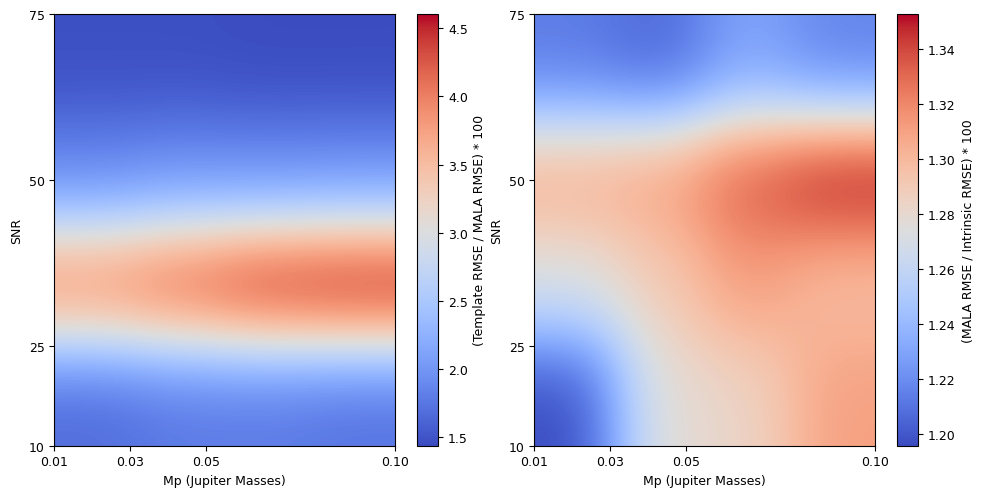

In [17]:
# Pivot the data so each method becomes a column
pivot = rmse.pivot_table(index="snr", columns="Mp_jupiter", values="sqrt_mean_error", aggfunc="mean")

# Extract the errors for each method separately
mala = rmse[rmse["method"] == "mala"].pivot(index="snr", columns="Mp_jupiter", values="sqrt_mean_error")
template = rmse[rmse["method"] == "template"].pivot(index="snr", columns="Mp_jupiter", values="sqrt_mean_error")
intrinsic = rmse[rmse["method"] == "intrinsic"].pivot(index="snr", columns="Mp_jupiter", values="sqrt_mean_error")


# Compute relative error (only where both exist)
relative_error = template/mala #* 100
re_er = mala/intrinsic #* 100

# Make the plot
fig, ax = plt.subplots(1,2,figsize=(10,5))
im = ax[0].imshow(relative_error, origin="lower", 
               aspect="auto",
               cmap="coolwarm",
               extent=[relative_error.columns.min(), relative_error.columns.max(),
                       relative_error.index.min(), relative_error.index.max()],
                       interpolation='gaussian')

im1 = ax[1].imshow(re_er, origin="lower", 
               aspect="auto",
               cmap="coolwarm",
               extent=[re_er.columns.min(), re_er.columns.max(),
                       re_er.index.min(), re_er.index.max()],
                       interpolation='gaussian')

# Labels
ax[0].set_xlabel("Mp (Jupiter Masses)")
ax[0].set_ylabel("SNR")
# ax.set_xscale("log")
cbar = plt.colorbar(im, ax=ax[0], label="(Template RMSE / MALA RMSE) * 100")
cbar = plt.colorbar(im1, ax=ax[1], label="(MALA RMSE / Intrinsic RMSE) * 100")

plt.tight_layout()
# plt.suptitle("Relative RMSE")
# # Optional: make ticks show actual values
ax[0].set_xticks([0.01,0.03,0.05,0.1])
ax[0].set_yticks(relative_error.index)
ax[1].set_xticks([0.01,0.03,0.05,0.1])
ax[1].set_yticks(relative_error.index)
ax[1].set_xlabel("Mp (Jupiter Masses)")
ax[1].set_ylabel("SNR")
plt.show()


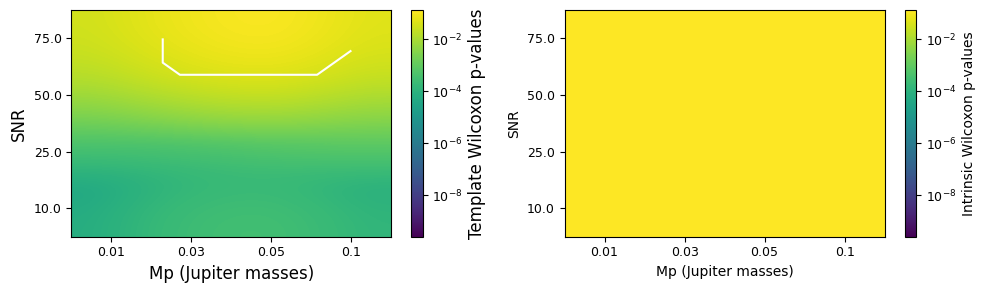

In [6]:
from matplotlib.colors import LogNorm
from scipy.ndimage import zoom

# Pivot into a 2D matrix: rows = snr, cols = Mp_jupiter, values = p_value
pivot = wilcoxon_results.pivot_table(
    index='snr', 
    columns='Mp_jupiter', 
    values='p_value_temp'
)

# Sort axes numerically if not already
pivot = pivot.sort_index(axis=0).sort_index(axis=1)

pivot1 = wilcoxon_results.pivot_table(
    index='snr', 
    columns='Mp_jupiter', 
    values='p_value_int'
)

# Sort axes numerically if not already
pivot1 = pivot1.sort_index(axis=0).sort_index(axis=1)

# Create figure
fig, ax = plt.subplots(1,2,figsize=(10, 3))

# Use log scale for p-values (optional: helps highlight significant regions)
im = ax[0].imshow(
    pivot,  # log10 for better dynamic range
    origin='lower', 
    aspect='auto', 
    cmap='viridis',
    interpolation='bicubic',
    norm=LogNorm(vmin=np.nanmin(pivot), vmax=np.nanmax(pivot))
)

im1 = ax[1].imshow(
    pivot1,  # log10 for better dynamic range
    origin='lower', 
    aspect='auto', 
    cmap='viridis',
    interpolation='bicubic',
    norm=LogNorm(vmin=np.nanmin(pivot), vmax=np.nanmax(pivot))
)

# Add colorbar
cbar = plt.colorbar(im, ax=ax[0])
cbar.set_label('Template Wilcoxon p-values', fontsize=12)

# Axis labels and ticks
ax[0].set_xlabel('Mp (Jupiter masses)', fontsize=12)
ax[0].set_ylabel('SNR', fontsize=12)

# Label ticks with actual Mp_jupiter and snr values
ax[0].set_xticks(np.arange(len(pivot.columns)))
ax[0].set_xticklabels(np.round(pivot.columns, 2))
ax[0].set_yticks(np.arange(len(pivot.index)))
ax[0].set_yticklabels(np.round(pivot.index, 2))


# Add colorbar
cbar = plt.colorbar(im1, ax=ax[1])
cbar.set_label('Intrinsic Wilcoxon p-values', fontsize=10)

# Axis labels and ticks
ax[1].set_xlabel('Mp (Jupiter masses)', fontsize=10)
ax[1].set_ylabel('SNR', fontsize=10)

# Label ticks with actual Mp_jupiter and snr values
ax[1].set_xticks(np.arange(len(pivot1.columns)))
ax[1].set_xticklabels(np.round(pivot1.columns, 2))
ax[1].set_yticks(np.arange(len(pivot1.index)))
ax[1].set_yticklabels(np.round(pivot1.index, 2))

# Optional: overlay significance threshold (e.g. p<0.05)
# --- interpolate for smoother contour ---
zoom_factor = 2  # increase for smoother contours
data_interp = zoom(pivot, zoom_factor, order=3)

# corresponding new coordinates
x = np.linspace(0, pivot.shape[1]-1, data_interp.shape[1])
y = np.linspace(0, pivot.shape[0]-1, data_interp.shape[0])

# threshold mask for p < 0.05
sig_mask = data_interp < 0.05
ax[0].contour(x, y, sig_mask, levels=[0.5], colors='white', linewidths=1.5)

plt.tight_layout()
plt.show()


# Zscore adjacent plots?

75.0 1.7908734826138044 1.2197362931883475 1.0260574337235147
75.0 1.8123977466975065 1.2536645418319483 1.0550968403679468
75.0 1.789929380720509 1.2000387616657653 1.0082286365146063
75.0 1.7685840126238643 1.2106723537822883 1.0316104687298002
50.0 3.0828237598405894 1.3003762075566627 1.0099747803669605
50.0 2.649360972012032 1.3482155657723878 1.042496039068095
50.0 2.6050172786883254 1.3524189271758005 1.0240501536694127
50.0 2.7216497720305015 1.278846569570093 0.9770868800332353
25.0 11.431210768434887 1.4013692900986767 1.1262604217163634
25.0 12.530206076974814 1.2958214573593887 1.0533687765792186
25.0 6.920270980287632 1.2567948941993343 1.0056243627050079
25.0 6.729436197638861 1.2658592964042072 1.0181346549884311
10.0 6.1327959870998185 0.7532267489585366 0.9682993960176309
10.0 4.251685476523692 0.9258044055691987 0.9418732974310793
10.0 4.06010629566327 0.9323994787229778 1.013066601246034
10.0 4.109493861450405 0.9382767044527616 0.9970216593305297


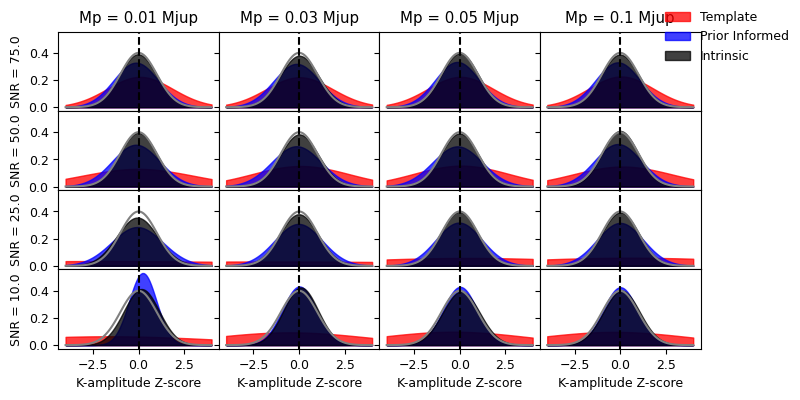

In [27]:
from scipy.stats import norm

# Example columns:
# ['Mp_jupiter', 'snr', 'method', 'realizations', 'Zscore', 'Ksigma']

# --- Assume df is your DataFrame ---
# Ensure numeric sorting
mp_vals = sorted(data['Mp_jupiter'].unique())
snr_vals = sorted(data['snr'].unique(),reverse=True)

# Set up grid
nrows = len(snr_vals)
ncols = len(mp_vals)

fig, axes = plt.subplots(nrows, ncols, figsize=(2*ncols, 1*nrows),sharex=True,sharey=True,gridspec_kw={'wspace': 0, 'hspace': 0})
# If there’s only one row/col, make sure axes is always 2D
axes = np.atleast_2d(axes)

for i, snr in enumerate(snr_vals):
    for j, mp in enumerate(mp_vals):
        ax = axes[i, j]
        subset = data[(data['Mp_jupiter'] == mp) & (data['snr'] == snr)]
        
        # Separate by method
        z_template = subset[subset['method'] == 'template']['Z_score'] 
        z_mala = subset[subset['method'] == 'mala']['Z_score'] 
        z_int = subset[subset['method'] == 'intrinsic']['Z_score'] 
        
        x = np.linspace(-4,4,100)
        ytemp = norm.pdf(x,np.mean(z_template),np.std(z_template))
        ymala = norm.pdf(x,np.mean(z_mala),np.std(z_mala))
        yint = norm.pdf(x,np.mean(z_int),np.std(z_int))
        normal = norm.pdf(x,0,1)
        ax.fill_between(x,np.zeros_like(x),ytemp,color="r",alpha=0.75,label="Template")
        ax.fill_between(x,np.zeros_like(x),ymala,color="b",alpha=0.75,label="Prior Informed")
        ax.fill_between(x,np.zeros_like(x),yint,color="k",alpha=0.75,label="Intrinsic")
        ax.plot(x,normal,color="gray")
        ax.axvline(0,c="k",ls="--")
        print(snr,np.std(z_template),np.std(z_mala),np.std(z_int))
        
        # Axes labels only on outer plots
        if i == nrows - 1:
            ax.set_xlabel("K-amplitude Z-score")
        if i == 0:#nrows - 1:
            ax.set_title(f"Mp = {mp} Mjup")
        if j == 0:
            ax.set_ylabel(f"SNR = {snr}")
        
        # ax.axvline(0, color='k', linestyle='--', lw=1)
        # ax.set_xlim(-5, 5)  # adjust to your Z-score range

# Add a single legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', frameon=False)

plt.tight_layout()
plt.subplots_adjust(top=0.93, right=0.88)
# fig.suptitle("Z-score Distributions of Retrieved K-Amplitudes", fontsize=14)
plt.show()


In [19]:
# --- find realization with largest (template_Z - mala_Z) ---
results = []

for (mp, snr), group in data.groupby(["Mp_jupiter", "snr"]):
    # pivot to align both methods by realization
    pivot = group.pivot(index="realization", columns="method", values="Z_score")
    
    # only keep realizations where both exist
    pivot = pivot.dropna(subset=["template", "mala"])
    
    if not pivot.empty:
        # compute difference
        pivot["diff"] = np.abs(pivot["template"]) - np.abs(pivot["mala"])
        
        # pick realization with largest difference
        best_real = pivot["diff"].idxmax()
        best_row = pivot.loc[best_real]
        
        results.append({
            "Mp_jupiter": mp,
            "snr": snr,
            "realization": best_real,
            "template_Z": best_row["template"],
            "mala_Z": best_row["mala"],
            "Z_diff": best_row["diff"]
        })

result_df = pd.DataFrame(results)


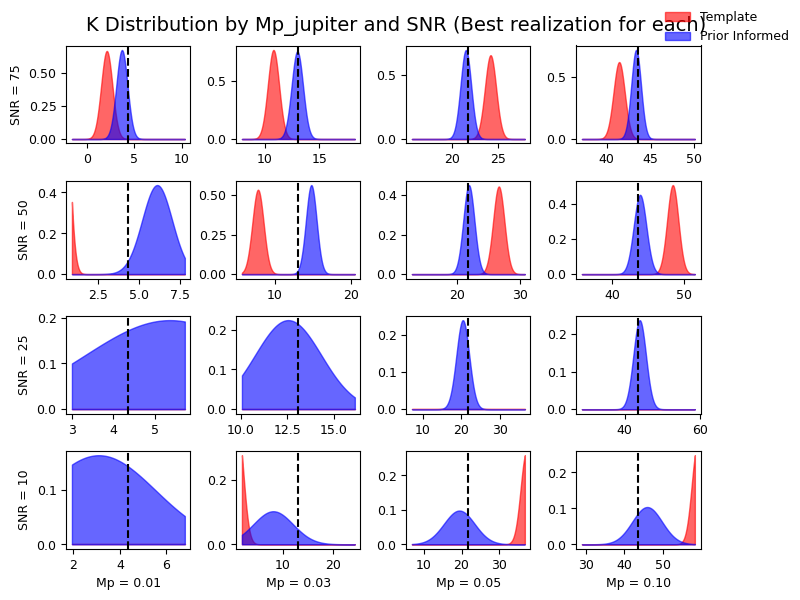

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

mp_vals = sorted(data['Mp_jupiter'].unique())
snr_vals = sorted(data['snr'].unique(), reverse=True)

nrows = len(snr_vals)
ncols = len(mp_vals)

fig, axes = plt.subplots(nrows, ncols, figsize=(2*ncols, 1.5*nrows))
axes = np.atleast_2d(axes)



for i, snr in enumerate(snr_vals):
    for j, mp in enumerate(mp_vals):
        ax = axes[i, j]
        nreal = result_df[(result_df['Mp_jupiter']==mp)&(result_df['snr']==snr)]['realization'].iloc[0]  # chosen realization
        subset = data[(data['Mp_jupiter'] == mp) & (data['snr'] == snr)]

        z_template = subset[(subset['method'] == 'template') & (subset['realization'] == nreal)]
        z_mala = subset[(subset['method'] == 'mala') & (subset['realization'] == nreal)]
        z_int = subset[(subset['method'] == 'intrinsic') & (subset['realization'] == nreal)]

        if len(z_template) == 0 or len(z_mala) == 0 or len(z_int) == 0:
            ax.axis("off")
            continue  # skip missing data

        # Convert to scalars
        mu_temp, sigma_temp = z_template["K_median"].iloc[0], z_template["K_sigma"].iloc[0]
        mu_mala, sigma_mala = z_mala["K_median"].iloc[0], z_mala["K_sigma"].iloc[0]
        true_val = z_int["K_true"].iloc[0]

        # Plot Gaussian PDFs
        x = np.linspace(true_val - 10*sigma_temp, true_val + 10*sigma_temp, 200)
        ytemp = norm.pdf(x, mu_temp, sigma_temp)
        ymala = norm.pdf(x, mu_mala, sigma_mala)

        ax.fill_between(x, np.zeros_like(x), ytemp, color="r", alpha=0.6, label="Template")
        ax.fill_between(x, np.zeros_like(x), ymala, color="b", alpha=0.6, label="Prior Informed")

        ax.axvline(true_val, c="k", ls="--")

        if i == nrows - 1:
            ax.set_xlabel(f"Mp = {mp:.2f}")
        if j == 0:
            ax.set_ylabel(f"SNR = {snr:.0f}")

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", frameon=False)

plt.tight_layout()
plt.subplots_adjust(top=0.93, right=0.88)
fig.suptitle("K Distribution by Mp_jupiter and SNR (Best realization for each)", fontsize=14)
plt.show()


In [21]:
# Pivot so we can compare template vs mala for each realization
gg = data[(data['Mp_jupiter']>0.02)&(data['snr']>15)]
pivot = gg.pivot_table(
    index=["Mp_jupiter", "snr", "realization"],
    columns="method",
    values="Z_score"
)

# Drop incomplete entries (where either method missing)
pivot = pivot.dropna(subset=["template", "mala"])

# Compute per-realization metrics across all Mp_jupiter, snr
summary = (
    pivot.groupby("realization")
    .agg(
        mean_abs_template=("template", lambda x: np.mean(np.abs(x))),
        mean_abs_mala=("mala", lambda x: np.mean(np.abs(x)))
    )
    .reset_index()
)

# Compute the "contrast" metric: large template |Z| and small mala |Z|
summary["contrast"] = summary["mean_abs_template"] - summary["mean_abs_mala"]

# Sort by contrast descending
summary = summary.sort_values(by="contrast", ascending=False).reset_index(drop=True)


75.0 0.5401107389055531 0.627204569241306
75.0 0.5948667999755441 0.5603803592302405
75.0 0.5608823744964937 0.5131706829724703
75.0 0.5467914241873011 0.6360841139456319
50.0 0.5609907120401928 0.8228159182974499
50.0 0.8634939310692431 0.800280830416165
50.0 0.8817065132516149 0.8478146671243181
50.0 0.8593133353553668 0.8723759698476172
25.0 1.6638812545956978 1.405983152332217
25.0 0.3501274639080699 1.5666442780308998
25.0 1.3719726301344304 1.645235909635069
25.0 1.4599662057597307 1.799677665875425
10.0 1.7615562825942042 2.8164387987036386
10.0 1.724453942243307 4.253596785621697
10.0 1.636795419212815 3.952146330781116
10.0 1.496915989575644 3.832624002159381


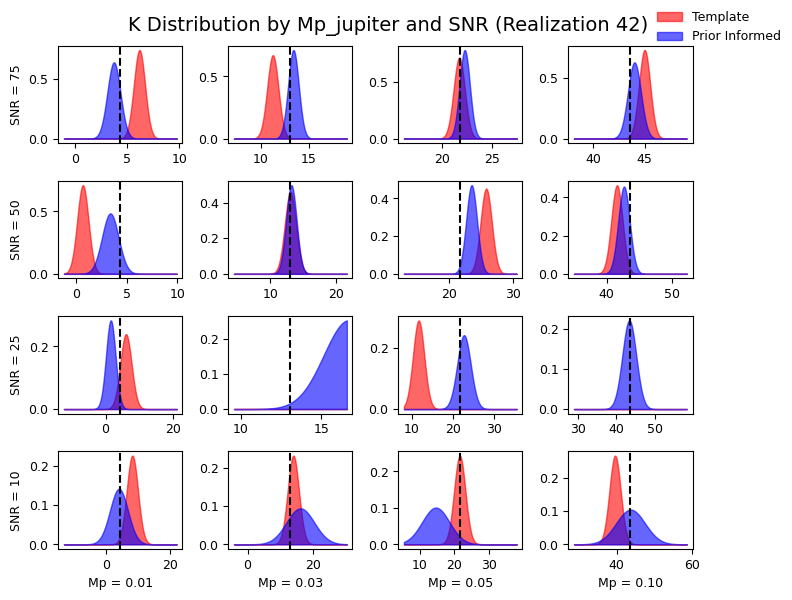

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

mp_vals = sorted(data['Mp_jupiter'].unique())
snr_vals = sorted(data['snr'].unique(), reverse=True)

nrows = len(snr_vals)
ncols = len(mp_vals)

fig, axes = plt.subplots(nrows, ncols, figsize=(2*ncols, 1.5*nrows))
axes = np.atleast_2d(axes)

nreal = summary['realization'].iloc[0]  # chosen realization

for i, snr in enumerate(snr_vals):
    for j, mp in enumerate(mp_vals):
        ax = axes[i, j]
        subset = data[(data['Mp_jupiter'] == mp) & (data['snr'] == snr)]

        z_template = subset[(subset['method'] == 'template') & (subset['realization'] == nreal)]
        z_mala = subset[(subset['method'] == 'mala') & (subset['realization'] == nreal)]
        z_int = subset[(subset['method'] == 'intrinsic') & (subset['realization'] == nreal)]

        if len(z_template) == 0 or len(z_mala) == 0 or len(z_int) == 0:
            ax.axis("off")
            continue  # skip missing data

        # Convert to scalars
        mu_temp, sigma_temp = z_template["K_median"].iloc[0], z_template["K_sigma"].iloc[0]
        mu_mala, sigma_mala = z_mala["K_median"].iloc[0], z_mala["K_sigma"].iloc[0]
        true_val = z_int["K_true"].iloc[0]
        # Plot Gaussian PDFs
        x = np.linspace(true_val - 10*sigma_temp, true_val + 10*sigma_temp, 200)
        ytemp = norm.pdf(x, mu_temp, sigma_temp)
        ymala = norm.pdf(x, mu_mala, sigma_mala)
        print(snr,sigma_temp,sigma_mala)
        ax.fill_between(x, np.zeros_like(x), ytemp, color="r", alpha=0.6, label="Template")
        ax.fill_between(x, np.zeros_like(x), ymala, color="b", alpha=0.6, label="Prior Informed")

        ax.axvline(true_val, c="k", ls="--")

        if i == nrows - 1:
            ax.set_xlabel(f"Mp = {mp:.2f}")
        if j == 0:
            ax.set_ylabel(f"SNR = {snr:.0f}")

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", frameon=False)

plt.tight_layout()
plt.subplots_adjust(top=0.93, right=0.88)
fig.suptitle("K Distribution by Mp_jupiter and SNR (Realization 42)", fontsize=14)
plt.show()


# Turn to actuall mass sensitivity 
- only consider snr<50 since this is where prior informed does better with fewer Nobs than template (in this case only 10 reliable obs but 20 to inform K amp)
- turn the Ksigma that we get in on prior informed to tell us what planetary systems we can now approach w new snr limits

In [23]:
dk_snr50 = np.mean(data[(data['snr']==50)&(data['method']=='mala')]['K_sigma'])
dk_snr25 = np.mean(data[(data['snr']==25)&(data['method']=='mala')]['K_sigma'])
dk_snr10 = np.mean(data[(data['snr']==10)&(data['method']=='mala')]['K_sigma'])

dks = np.array([dk_snr10,dk_snr25,dk_snr50])


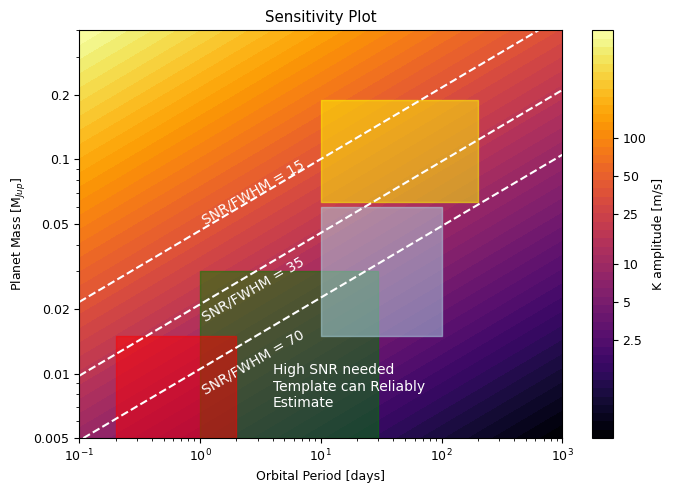

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def get_K(P_days, Mp_jupiter, Ms_solar):
    return 28.4 * ((P_days / 365.2422) ** (-1/3)) * Mp_jupiter * (Ms_solar ** (-2/3))

# Grid
P = np.logspace(-1, 3, 100)  # days
Mp = np.linspace(0.005, 0.4, 100)  # Jupiter masses
Ks = get_K(P[np.newaxis, :], Mp[:, np.newaxis], 0.12)

# Create figure
fig, ax = plt.subplots(figsize=(7,5))
P_grid, Mp_grid = np.meshgrid(P, Mp)

# Make levels logarithmic but biased toward smaller values
num_levels = 50
levels = np.logspace(np.log10(Ks.min()), np.log10(Ks.max()), num_levels)

# Filled contour
cf = ax.contourf(
    P_grid,
    Mp_grid,
    Ks,
    levels=levels,
    cmap='inferno',
    norm=LogNorm(vmin=Ks.min(), vmax=Ks.max())
)

contour_levels = np.flip(dks*10)  # K values
P_grid, Mp_grid = np.meshgrid(P, Mp)
cs = ax.contour(
    P_grid,
    Mp_grid,
    Ks,
    levels=contour_levels,
    colors='white',
    linewidths=1.5,
    linestyles="--"
)

ax.fill_between(np.linspace(1,30),0.005,0.03,color='green',alpha=0.5)
ax.fill_between(np.linspace(10,100),0.015,0.06,color='lightblue',alpha=0.5)
ax.fill_between(np.linspace(10,200),0.063,0.19,color='yellow',alpha=0.5)
ax.fill_between(np.linspace(0.2,2),0.005,0.015,color='red',alpha=0.5)


ax.text(1, 0.05, "SNR/FWHM = 15", color='white', fontsize=10,rotation=30)
ax.text(1, 0.0175, "SNR/FWHM = 35", color='white', fontsize=10,rotation=30)
ax.text(1, 0.008, "SNR/FWHM = 70", color='white', fontsize=10,rotation=30)
ax.text(4, 0.007, "High SNR needed\nTemplate can Reliably\nEstimate", color='white', fontsize=10)

# Axes
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Orbital Period [days]')
ax.set_ylabel('Planet Mass [M$_{Jup}$]')
ax.set_title('Sensitivity Plot')

yticks = [0.005,0.01,0.02,0.05,0.1,0.2]
ax.set_yticks(yticks)
ax.set_yticklabels([str(y) for y in yticks]) 

# Colorbar
# Example: set ticks manually
cbar = plt.colorbar(cf, ax=ax)

# Define specific K values for ticks
tick_values = [2.5,5,10,25,50,100]  # whatever makes sense for your K range

# Apply LogNorm correctly
cbar.set_ticks(tick_values)          # set tick locations
cbar.set_ticklabels([str(v) for v in tick_values])  # set labels

cbar.set_label('K amplitude [m/s]')

plt.tight_layout()
plt.show()


In [25]:
5/317, 0.5/317

(0.015772870662460567, 0.0015772870662460567)